In [1]:
# >>> repo-root chdir setup >>>
import os
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    return start
_root = _find_repo_root(Path(os.getcwd()).resolve())
if Path(os.getcwd()).resolve() != _root:
    os.chdir(_root)
print('CWD:', os.getcwd())
# <<< repo-root chdir setup <<<


CWD: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


# Feature Consistency Audit Notebook

This notebook audits feature schema, direction-invariance, and formula consistency for the CLEAN pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from pathlib import Path

features = pd.read_parquet("artifacts/clean_pipeline/features.parquet")

with open("artifacts/clean_pipeline/feature_columns.json") as f:
    feature_columns = json.load(f)

## 1. Required input schema

In [3]:
required = [
    "flow_id",
    "capture_id",
    "dataset",
    "label",
    "timestamps",
    "sizes",
    "directions"
]

print("Required input columns:", required)

schema_present = all(col in features.columns for col in required)

print("Present in features:", schema_present)

Required input columns: ['flow_id', 'capture_id', 'dataset', 'label', 'timestamps', 'sizes', 'directions']
Present in features: True


## 2. Final feature schema

In [4]:
print("Model feature columns from artifact:")
print(feature_columns)

print("\nFeatures DataFrame columns:")
print(list(features.columns))

Model feature columns from artifact:
['sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets', 'packet_rate', 'byte_rate']

Features DataFrame columns:
['flow_id', 'capture_id', 'dataset', 'split', 'label', 'timestamps', 'sizes', 'directions', 'flow_duration', 'total_packets', 'total_bytes', 'packet_rate', 'byte_rate', 'sz_coef_variation', 'sz_p25_median_ratio', 'sz_p75_median_ratio', 'sz_iqr_norm_median', 'dispersion_symmetry', 'direction_balance_bytes', 'direction_balance_packets']


## 3. Excluded metadata/risky features

In [5]:
risky_patterns = [
    "fwd",
    "bwd",
    "forward",
    "backward",
    "src",
    "dst",
    "client",
    "server",
    "directional_ratio"
]

risky = [
    f for f in feature_columns
    if any(p in f.lower() for p in risky_patterns)
]

print("Risky features in model columns:", risky)

Risky features in model columns: []


## 4. Rate feature formula consistency

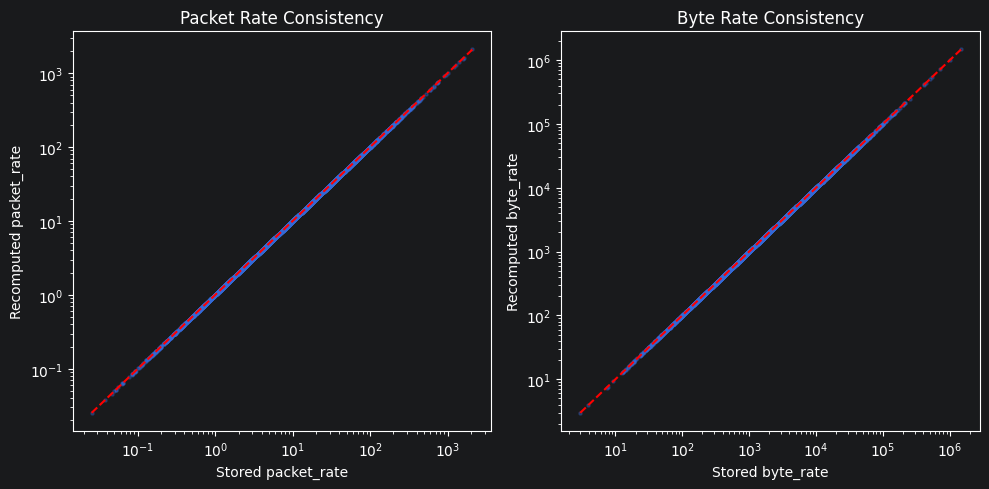

Max abs error packet_rate: 0.0
Max abs error byte_rate: 0.0


In [6]:
df = features[features["flow_duration"] > 0].copy()

recomputed_packet_rate = df["total_packets"] / df["flow_duration"]
recomputed_byte_rate = df["total_bytes"] / df["flow_duration"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(
    df["packet_rate"],
    recomputed_packet_rate,
    alpha=0.3,
    s=5
)

axes[0].plot(
    [df["packet_rate"].min(), df["packet_rate"].max()],
    [df["packet_rate"].min(), df["packet_rate"].max()],
    "r--"
)

axes[0].set_xlabel("Stored packet_rate")
axes[0].set_ylabel("Recomputed packet_rate")
axes[0].set_title("Packet Rate Consistency")
axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[1].scatter(
    df["byte_rate"],
    recomputed_byte_rate,
    alpha=0.3,
    s=5
)

axes[1].plot(
    [df["byte_rate"].min(), df["byte_rate"].max()],
    [df["byte_rate"].min(), df["byte_rate"].max()],
    "r--"
)

axes[1].set_xlabel("Stored byte_rate")
axes[1].set_ylabel("Recomputed byte_rate")
axes[1].set_title("Byte Rate Consistency")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("figures/validation/rate_feature_formula_consistency.png")
plt.show()

max_packet_rate_error = np.max(
    np.abs(df["packet_rate"] - recomputed_packet_rate)
)

max_byte_rate_error = np.max(
    np.abs(df["byte_rate"] - recomputed_byte_rate)
)

print("Max abs error packet_rate:", max_packet_rate_error)
print("Max abs error byte_rate:", max_byte_rate_error)

## 5. Save feature consistency summary

In [7]:
summary = [
    {
        "check_name": "rate_formula_consistency",
        "status": "PASS"
        if max_packet_rate_error < 1e-6 and max_byte_rate_error < 1e-6
        else "FAIL",
        "feature_count": len(feature_columns),
        "missing_features": [
            f for f in feature_columns
            if f not in features.columns
        ],
        "extra_features": [
            f for f in features.columns
            if f not in feature_columns
        ],
        "max_absolute_formula_error": float(
            max(max_packet_rate_error, max_byte_rate_error)
        ),
        "notes": ""
    }
]

pd.DataFrame(summary).to_csv(
    "artifacts/validation/feature_consistency_summary.csv",
    index=False
)

with open("artifacts/validation/feature_consistency_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame(summary)

,check_name,status,feature_count,missing_features,extra_features,max_absolute_formula_error,notes
0,rate_formula_consistency,PASS,9,[],"[flow_id, capture_id, dataset, split, label, t...",0.0,
